In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score


In [2]:
from sklearn.datasets import load_wine
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

In [3]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
x=df.drop('target', axis=1)
y=df['target']

In [5]:
sc=StandardScaler()
x=sc.fit_transform(x)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
model=RandomForestClassifier(n_estimators=100,oob_score=True,random_state=42,bootstrap=True)
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]


In [6]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("OOB Score:", model.oob_score_)

Test Accuracy: 1.0
OOB Score: 0.9838709677419355


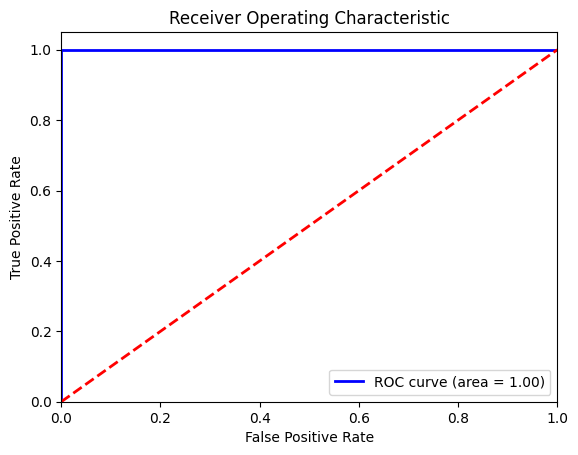

In [7]:
#roc curve
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [8]:
print("AUC value:", roc_auc)

AUC value: 1.0


In [9]:
#cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
sim=cosine_similarity([x_test[0]], [x_test[1]])[0][0]
print("Cosine Similarity:", sim)

Cosine Similarity: 0.7213451471821604


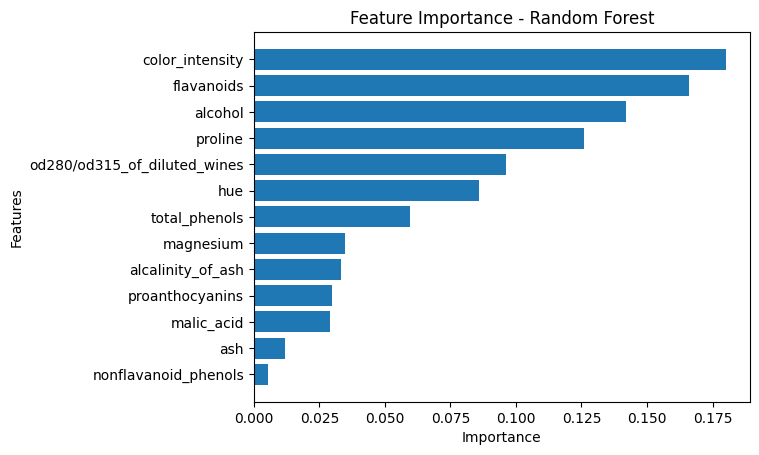

In [10]:
feature_names = wine.feature_names
importances = model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()   
plt.show()

In [11]:
#overlap between test and train dataset
df_train = pd.DataFrame(x_train)
df_test = pd.DataFrame(x_test)
overlap = pd.merge(df_train, df_test, how='inner')
print("Number of overlapping samples:", len(overlap))

Number of overlapping samples: 0


In [12]:
#bagging classifier
from sklearn.ensemble import BaggingClassifier
bagging_model = BaggingClassifier(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    n_estimators=10,
    random_state=42
)

bagging_model.fit(x_train, y_train)

y_pred_bagging = bagging_model.predict(x_test)

print(classification_report(y_test, y_pred_bagging))
print("Test Accuracy (Bagging):", accuracy_score(y_test, y_pred_bagging))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Test Accuracy (Bagging): 0.9814814814814815


In [13]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("OOB Score:", model.oob_score_)

Test Accuracy: 1.0
OOB Score: 0.9838709677419355


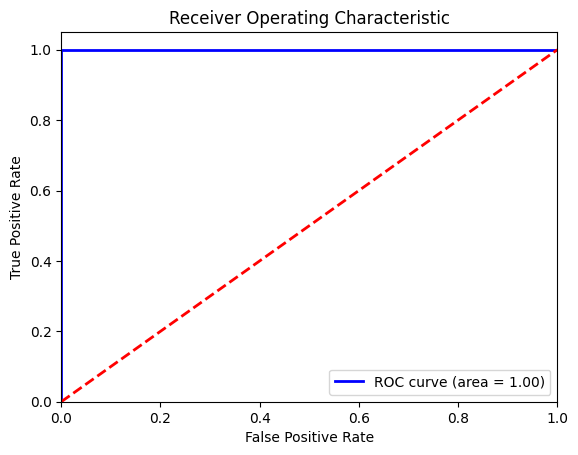

In [14]:
#roc curve
from sklearn.metrics import roc_curve, auc
y_prob = bagging_model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

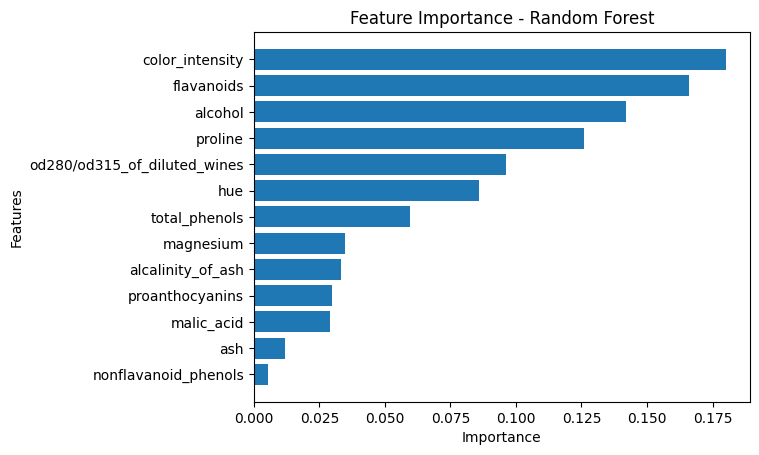

In [15]:
feature_names = wine.feature_names
importances = model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()   
plt.show()